# Parte 2 - EDA y Visualización de Datos

# Cargando los datos (previamente limpiados)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid') # Seleccionamos un estilo para las gráficas, yo seleccioné el estilo 'darkgrid'

df=pd.read_csv('Final_DataFrame.csv',index_col=0) # index_col=0 indica que la primera colmna será el índice

# Vista general de los datos

In [3]:
df

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT
0,2022-08-28,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
1,2022-08-28,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
2,2022-08-28,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
3,2022-08-28,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
4,2022-08-28,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,2023-07-03,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
121998,2023-07-03,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER O2 PRE-LAVADOR BOT.ATOM. 650 ML N...,FABRIC TREATMENT and SANIT,LIQUIDO,PRELAVADOR,FABRIC TREATMENT,ROSA,PRETREAT
121999,2023-07-03,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER O2 DOYPACK 120 GR 7501058753441,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
122000,2023-07-03,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
 6   MANUFACTURER                 122002 non-null  object 
 7   BRAND                        122002 non-null  object 
 8   ITEM_DESCRIPTION             122002 non-null  object 
 9   CATEGORY                     122002 non-null  object 
 10  FORMAT                       122002 non-null  object 
 11  ATTR1                        122002 non-null  object 
 12  ATTR2                        122002 non-null  object 
 13 

Véase que la columna "WEEK" no se cargó en formato de fecha (dtype='object'), por lo que se cambiará a formato de fecha para poder hacer una mejor visualización de datos referente a este parámetro

In [5]:
df['WEEK'] = pd.to_datetime(df['WEEK']) #Cambiamos solo la columna 'WEEK' a formato de decha (datetime)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   WEEK                         122002 non-null  datetime64[ns]
 1   ITEM_CODE                    122002 non-null  object        
 2   TOTAL_UNIT_SALES             122002 non-null  float64       
 3   TOTAL_VALUE_SALES            122002 non-null  float64       
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64       
 5   REGION                       122002 non-null  object        
 6   MANUFACTURER                 122002 non-null  object        
 7   BRAND                        122002 non-null  object        
 8   ITEM_DESCRIPTION             122002 non-null  object        
 9   CATEGORY                     122002 non-null  object        
 10  FORMAT                       122002 non-null  object        
 11  ATTR1                     

# Identificar las variables clave para el análisis

Una de las preguntas de la empresa es si sus marcas Vanish y Lysol están teniendo un buen desempeño, por lo que será importante comparar entre diferentes marcas (columna 'BRAND')

In [6]:
df['BRAND'].unique() #Con .unique(), podemos ver cuáles son las diferentes categorías que aparecen en esta columna

array(['VANISH', 'SHOUT', 'LA VALENCIANA', 'LOS PATITOS', 'OXI CLEAN',
       'CLARASOL', 'CLOROX', 'DR.BECKMANN', 'CLORALEX',
       'CUELLOS PUNOS Y MANCHITAS', 'BANDERA', 'BCLORHADA', 'PURO SOL',
       'OTHERS MARCA UNIF.', 'TIDE', 'LYSOL', 'BLANCATEL', 'CLORALUZ',
       'CLORTEX', 'PATITO', 'SANYTOL', 'IBERIA', 'LA JAPONESA', 'HARPIC'],
      dtype=object)

También se pregunta sobre quiénes son los competidores clave en cada segmento (columna 'SEGMENT'), además de que se pregunta si los productos sanitizantes han tenido buen desempeño ('SEGMENT': 'SANITIZER')

In [7]:
df['SEGMENT'].unique() 

array(['POWDER', 'PRETREAT', 'BAR', 'LIQUID & GEL', 'BLEACH', 'SANITIZER',
       'OTHERS'], dtype=object)

Otra variable clave es la región de las ventas, para analizar la demografía y el alcance de los productos (columna 'REGION')

In [8]:
df['REGION'].unique()

array(['TOTAL AUTOS AREA 5', 'TOTAL AUTOS AREA 6',
       'TOTAL AUTOS SCANNING MEXICO', 'TOTAL AUTOS AREA 3',
       'TOTAL AUTOS AREA 2', 'TOTAL AUTOS AREA 1', 'TOTAL AUTOS AREA 4'],
      dtype=object)

Por simplicidad, se cambiará el nombre de las regiones, quitando el 'TOTAL AUTOS' en cada etiqueta

In [9]:
df['REGION']=df['REGION'].replace(['TOTAL AUTOS AREA 1','TOTAL AUTOS AREA 2','TOTAL AUTOS AREA 3','TOTAL AUTOS AREA 4','TOTAL AUTOS AREA 5','TOTAL AUTOS AREA 6','TOTAL AUTOS SCANNING MEXICO'], 
                                  ['AREA 1','AREA 2','AREA 3','AREA 4','AREA 5','AREA 6','SCANNING MEXICO'])
df['REGION'].unique()

array(['AREA 5', 'AREA 6', 'SCANNING MEXICO', 'AREA 3', 'AREA 2',
       'AREA 1', 'AREA 4'], dtype=object)

Cabe aclarar que, si bien sería analizar la categoría de los productos, parece que no es una variable relevante, pues todos los datos pertenecen a una sola categoría

In [10]:
df['CATEGORY'].unique() 

array(['FABRIC TREATMENT and SANIT'], dtype=object)

Todas estas variables serán comparadas con las ventas semanales. Es fácil identificar que la columna 'WEEK' será necesaria para este análisis, lo que no es tan sencillo es elegir qué columna elegir para tomar como las ventas semanales. En la base de datos, contamos con 3 columnas con datos de ventas:
- **"TOTAL_UNIT_SALES" (Ventas Totales en Unidades):** Esta columna indica cuántos artículos individuales se vendieron en esa semana específica.
- **"TOTAL_VALUE_SALES" (Ventas Totales Monetarias):** Representa los ingresos brutos generados por esas ventas. 
- **"TOTAL_UNIT_AVG_WEEKLY_SALES" (Promedio de Ventas Semanales en Unidades):** Esta es una métrica de rendimiento histórico o referencial, indicando cuál es el comportamiento "normal" o promedio del producto en un periodo determinado.

Estas definiciones no fueron proporcionadas directamente por la empresa, pero son interpretaciones obtenidas a partir de los estándares ya establecidos. Para confirmar esto rápidamente, se analizarán con gráficas de dispersión si existe alguna correlación entre estas variables.

## Gráficos de dispersión

Primero, observaremos la relación que hay entre "TOTAL_UNIT_SALES" vs "TOTAL_VALUE_SALES". Si estas columnas realmente representan las ventas unitarias y las ventas monetarias, respectivamente, se debería observar una fuerte correlación entre estas, ya que las ventas monetarias son el resultado de multiplicar las unidades vendidas por el precio de venta, aunque la relación no se verá perfectamente, ya que la base de datos cuenta con múltiples productos con diferentes precios cada uno.

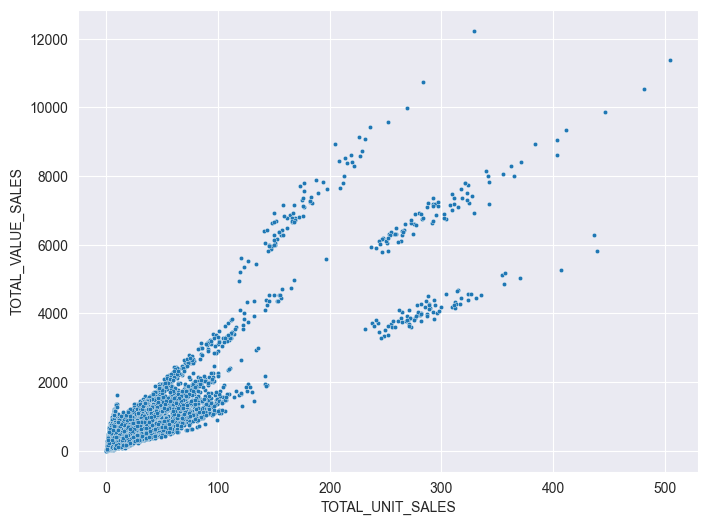

In [41]:
f, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(df, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', s=10)
plt.show()

Podemos observar que sí existe una correlación positiva visible entre estas variables, afirmando la hipótesis que se tenía.

Ahora, revisaremos la relación que hay entre "TOTAL_UNIT_SALES" vs "TOTAL_UNIT_AVG_WEEKLY_SALES". Si la segunda columna mencionada representa un rendimiento histórico de las ventas, no debería de haber una correlación clara con las ventas unitarias.

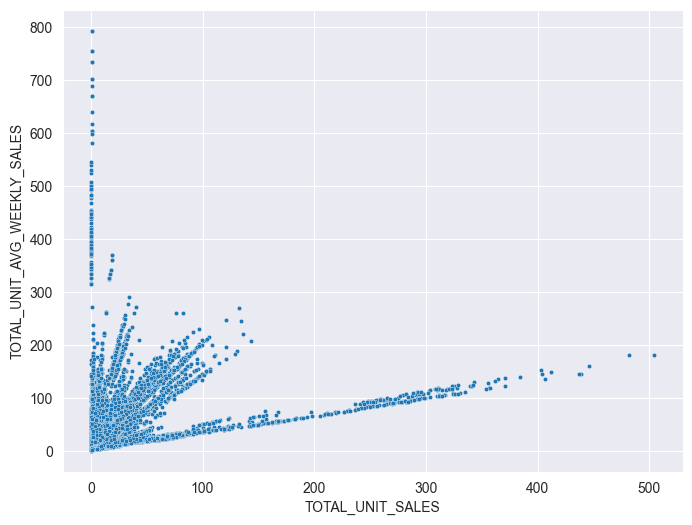

In [42]:
f, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(df, x='TOTAL_UNIT_SALES', y='TOTAL_UNIT_AVG_WEEKLY_SALES', s=10)
plt.show()

Aquí se puede ver que el gráfico de dispersión no muestra una correlación clara en los datos. Si bien hay secciones que parecen estar correlacionadas, los datos en general no tienen un patrón claro.

Finalmente, analizaremos la relación que hay entre "TOTAL_UNIT_SALES" vs "TOTAL_UNIT_AVG_WEEKLY_SALES". Dada la proporcionalidad presente entre las ventas unitarias y monetarias, la siguiente gráfica debería verse de forma muy similar a la anterior.

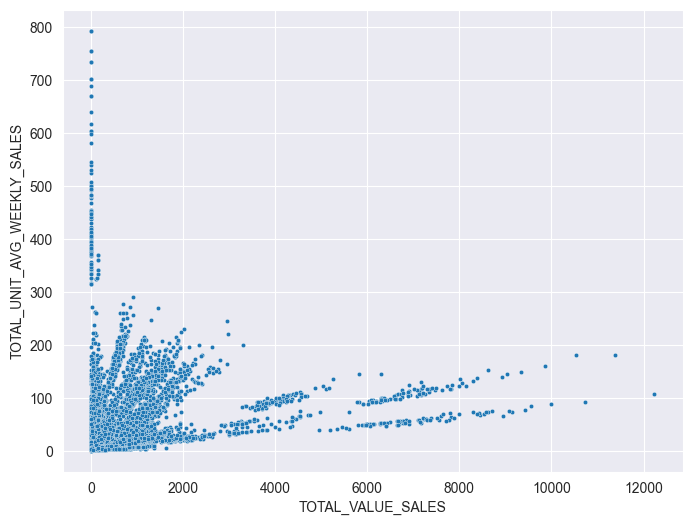

In [43]:
f, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(df, x='TOTAL_VALUE_SALES', y='TOTAL_UNIT_AVG_WEEKLY_SALES', s=10)
plt.show()

En esta gráfica se puede confirmar que la forma de la gráfica es muy similar a la anterior.

Dada la confirmación del comportamiento de los datos, podemos elegir entre 'TOTAL_UNIT_SALES' o 'TOTAL_VALUE_SALES' para hacer el análisis exploratorio de las ventas. En este caso, se decidió trabajar con 'TOTAL_UNIT_SALES', debido a que la escala de los datos es más pequeña y manejable para las gráficas.

Por lo tanto, las variables clave son: 'BRAND', 'SEGMENT', 'REGION', 'TOTAL_UNIT_SALES' y 'WEEK'

In [11]:
df_clave=df.copy()
df_clave=df_clave[['BRAND', 'SEGMENT', 'REGION', 'TOTAL_UNIT_SALES', 'WEEK']]
#renobramos la columna 'TOTAL_UNIT_SALES' a un nombre más simple: 'WEEKLY_SALES'
df_clave.rename(columns={'TOTAL_UNIT_SALES':'WEEKLY_SALES'}, inplace=True) 
df_clave

,BRAND,SEGMENT,REGION,WEEKLY_SALES,WEEK
0,VANISH,POWDER,AREA 5,0.006,2022-08-28
1,VANISH,POWDER,AREA 5,0.487,2022-08-28
2,VANISH,POWDER,AREA 5,1.391,2022-08-28
3,VANISH,POWDER,AREA 5,0.022,2022-08-28
4,VANISH,POWDER,AREA 5,2.037,2022-08-28
...,...,...,...,...,...
121997,VANISH,POWDER,SCANNING MEXICO,1.192,2023-07-03
121998,VANISH,PRETREAT,SCANNING MEXICO,1.947,2023-07-03
121999,VANISH,POWDER,SCANNING MEXICO,18.013,2023-07-03
122000,VANISH,POWDER,SCANNING MEXICO,21.152,2023-07-03


# Distribución de ventas

Primero, para detectar outliers, se analizarán boxplots divididos en categorías

Empezamos por analizar los boxplots por segmentos

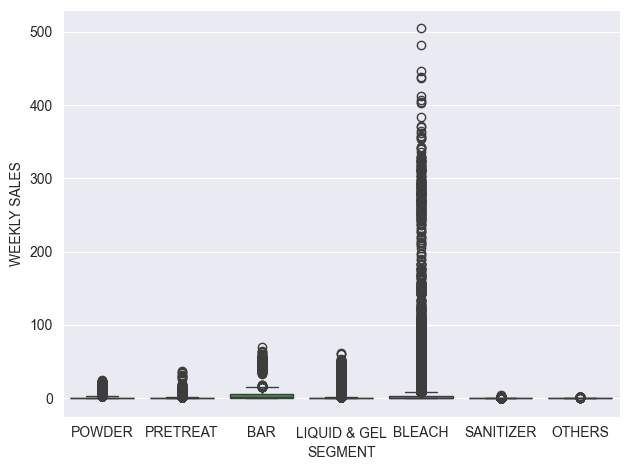

In [45]:
sns.boxplot(df_clave, y='WEEKLY_SALES', x='SEGMENT', hue='SEGMENT')
plt.ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por segmento.png')
plt.show()

El segmento "BLEACH" tiene muchos outliers muy altos, lo que no permite ver claramente los boxplots de los demás segmentos, por lo que se hará un corte en el eje y

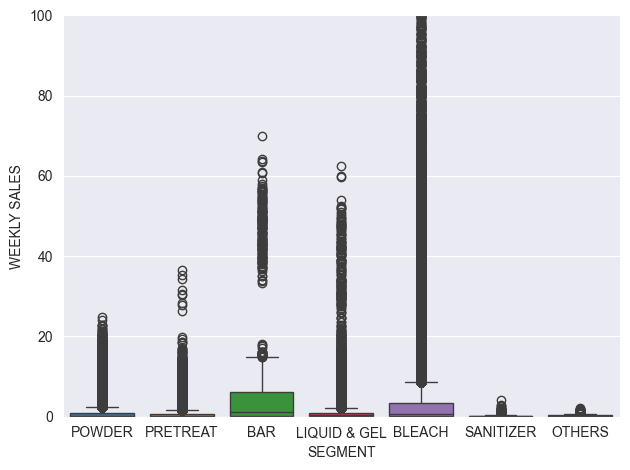

In [46]:
sns.boxplot(df_clave, y='WEEKLY_SALES', x='SEGMENT', hue='SEGMENT')
plt.ylim(0,100)
plt.ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por segmento con zoom.png')
plt.show()

Se puede observar que, mientras que el segmento "BAR" tiene una distribución de ventas bastante consistente, todos los demás cuentan con una cantidad considerable de outliers, en especial los segmentos "BLEACH", "LIQUID & GEL", "PRETREAT" y "POWDER".

Ahora, analizando los boxplots por marca

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\924731335.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


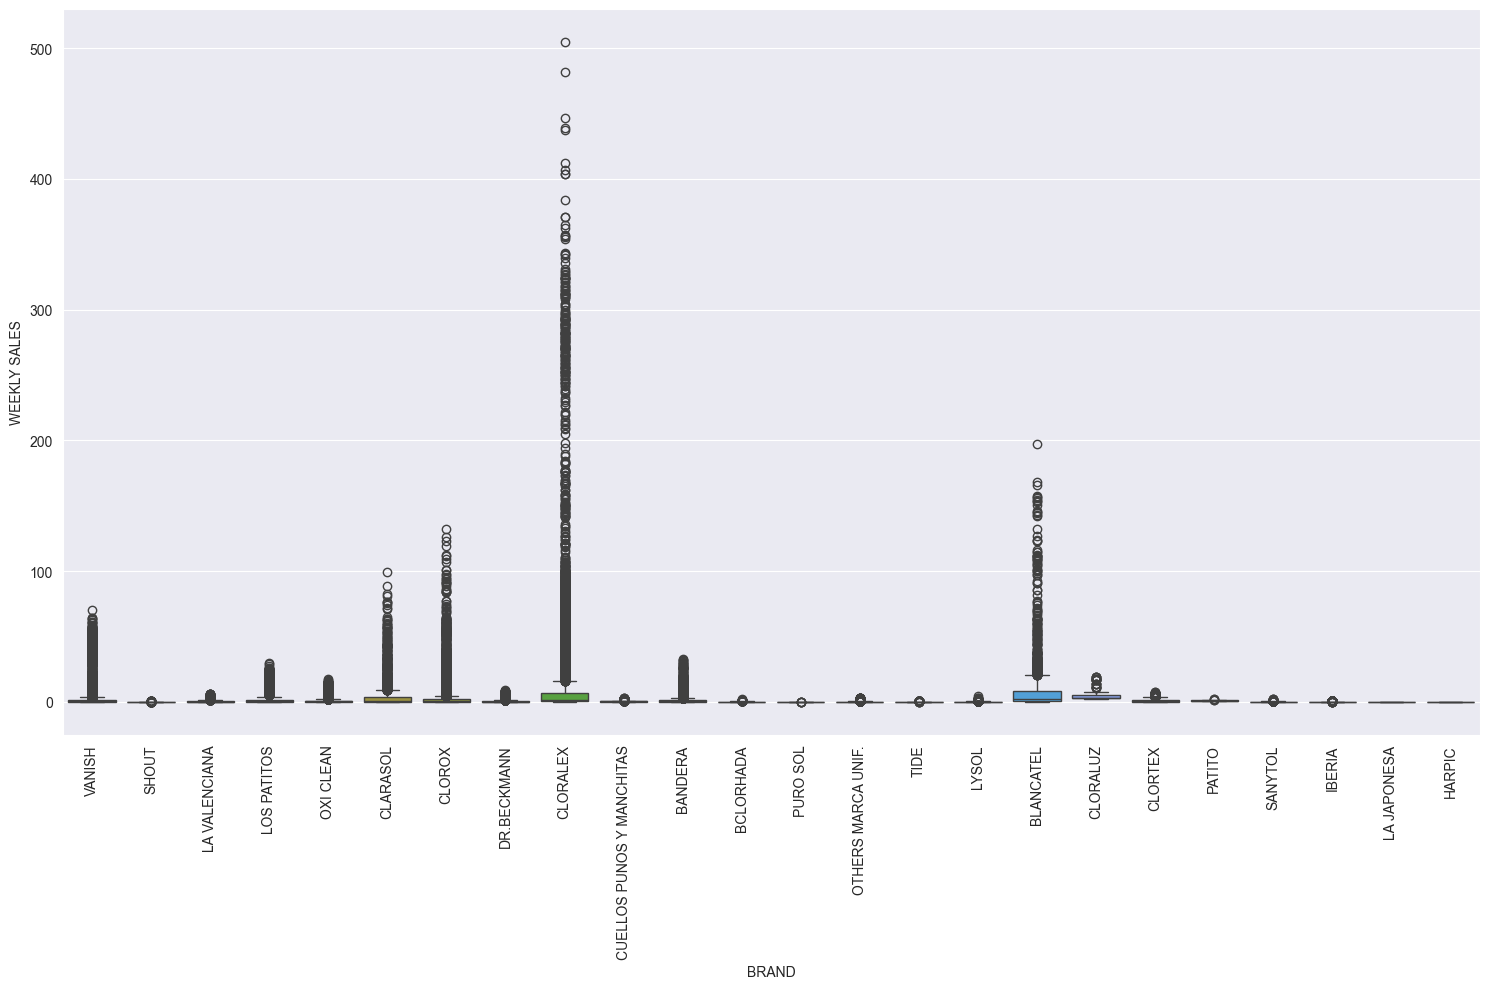

In [47]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='BRAND', hue='BRAND', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por marca.png')
plt.show()

Volvemos a hacer un corte en y, dado que los outliers más grandes solo son de una marca

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\1833318479.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


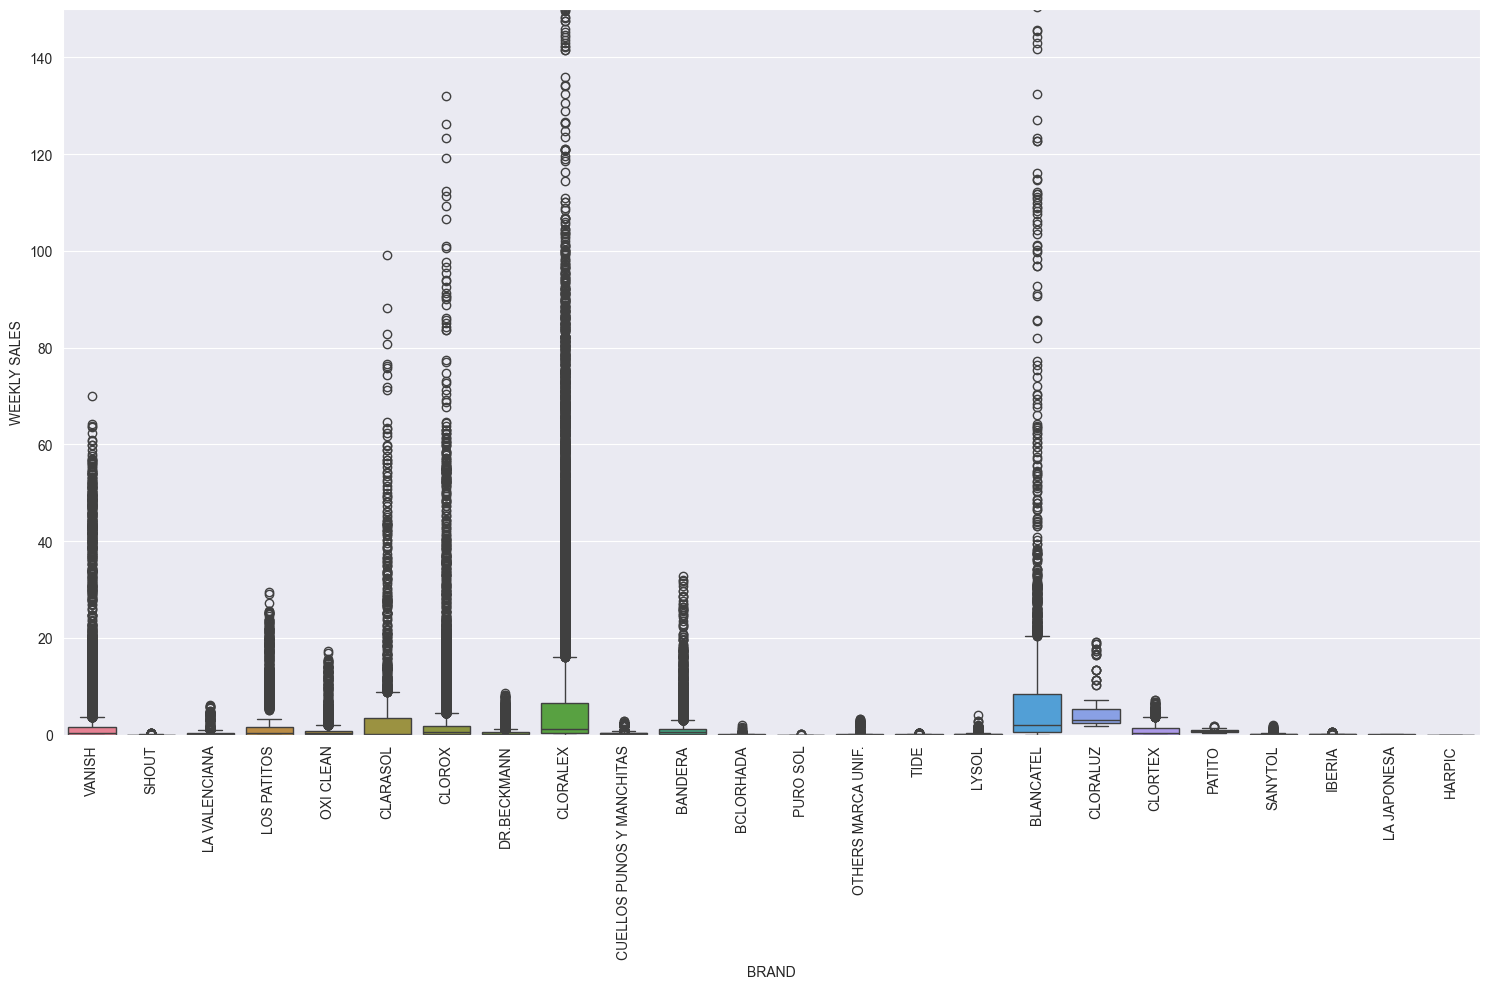

In [50]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='BRAND', hue='BRAND', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
ax.set_ylim(0,150)
plt.tight_layout()
plt.savefig('Boxplot por marca con zoom.png')
plt.show()

Se observa que hay marcas con distribuciones consistentes y con pocos outliers como "PATITO", "CLORALUZ" y "TIDE", en cambio, marcas como "CLOROX", "CLORALEX" y "BLANCATEL" tienen una gran cantidad de outliers. Además, los outliers más grandes y significativos pertenecen a la marca "CLORALEX" y al segmento "BLEACH".

Respecto a las marcas de interés, se observa que "VANISH" cuenta con bastantes outliers grandes y "LYSOL" con outliers pero más pequeños. Desde aquí también se ve que las ventas de Lysol no son de las mejores en comparación con otras marcas, a diferencia de Vanish que todavía tiene una presencia significante en el mercado.

# Geografía de las ventas

Analizando ahora las distribuciones por región

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\4169518499.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


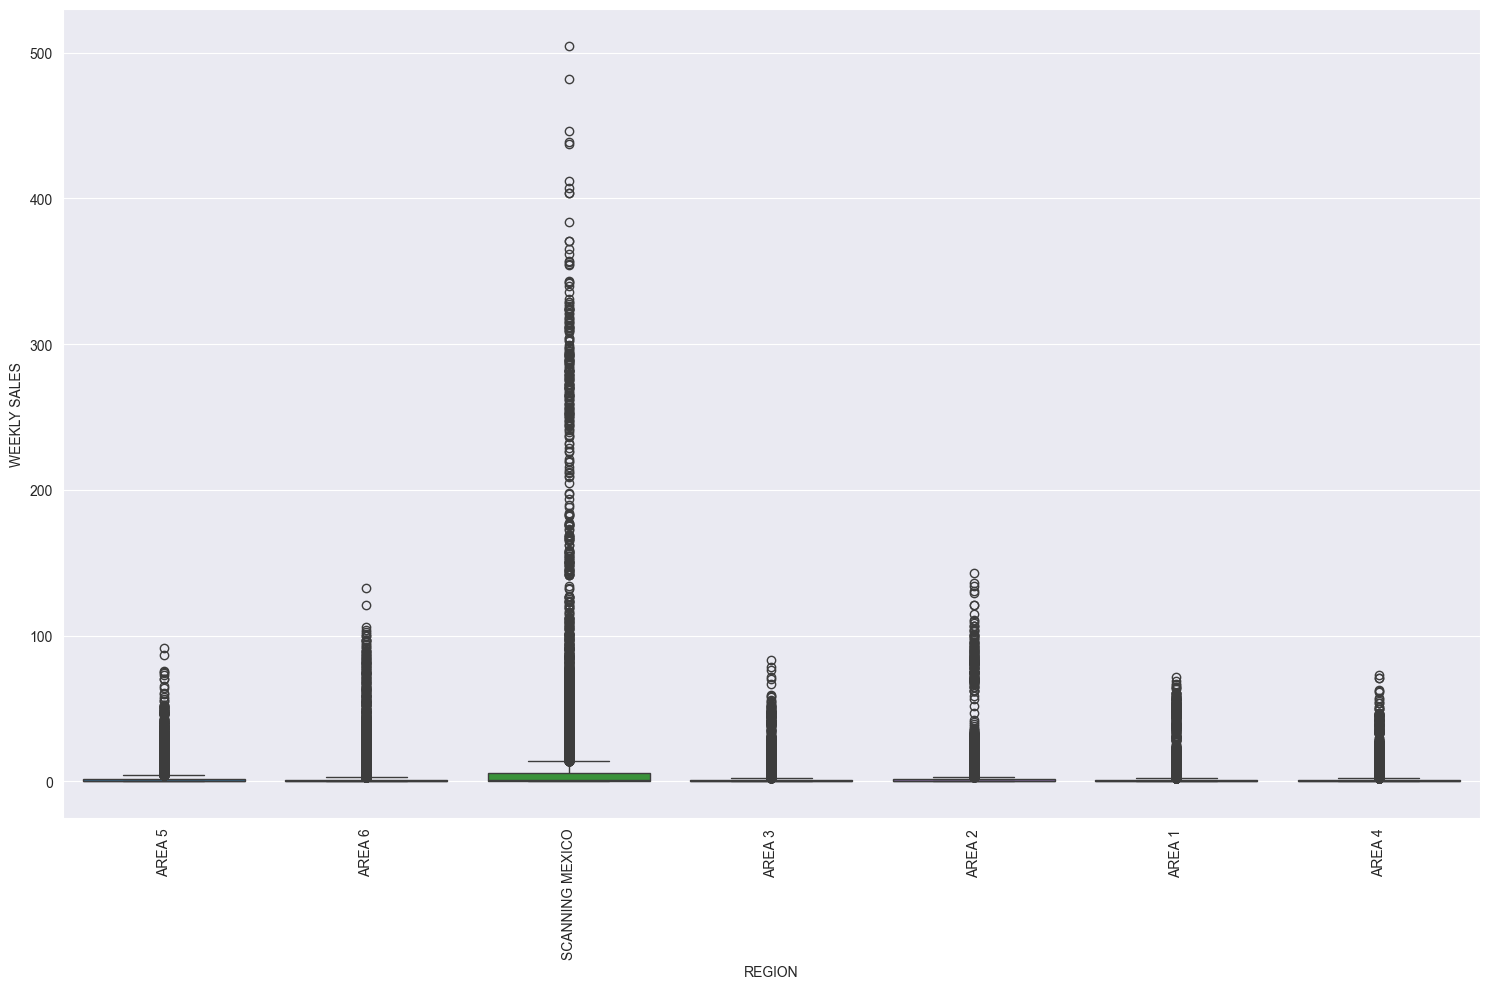

In [51]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='REGION', hue='REGION', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por region.png')
plt.show()

En general, las distribuciones de las regiones son muy parecidas, teniendo todas una cantidad considerable de outliers, teniendo "SCANNING MEXICO" los outliers más marcados.

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\2558313911.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


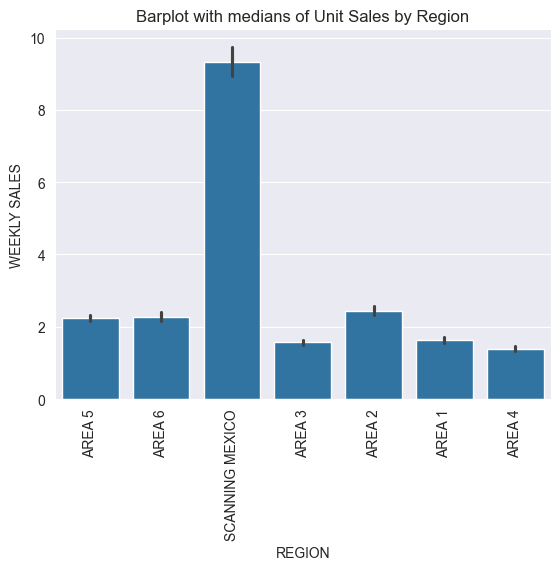

In [54]:
fig, ax = plt.subplots()
sns.barplot(df_clave, x='REGION', y='WEEKLY_SALES', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.title('Barplot with medians of Unit Sales by Region')
plt.savefig('Grafico de barras por region.png')
plt.show()

Al comparar las medianas de las ventas semanales por región (lo ploteado en barplot), se observa que "SCANNING MEXICO" destaca considerablemente sobre todas las regiones, lo que indica que las ventas semanales en esta región son en general muy buenas. Las demás regiones tienen ventas menores, destacando solamente las regiones "AREA 2", "AREA 6" y "AREA 5" con las mayores medianas de las ventas semanales.

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\1995346834.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


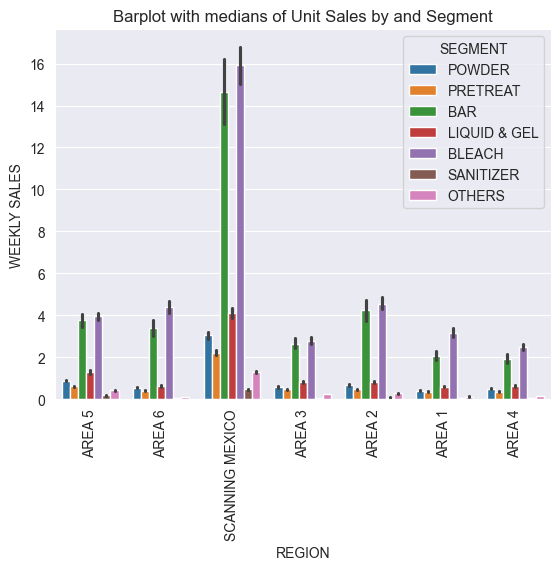

In [55]:
fig, ax = plt.subplots()
sns.barplot(df_clave, x='REGION', y='WEEKLY_SALES', hue='SEGMENT', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.title('Barplot with medians of Unit Sales by and Segment')
plt.savefig('Grafico de barras por region y segmento.png')
plt.show()

Analizando las distribuciones por región subdivididas por segmento, se observa que los segmentos tienen formas casi iguales en cada región, siendo los "SANITIZER", "OTHERS", "PRETREAT", "POWDER" y "LIQUID & GEL" los segmentos con menor rendimiento (ordenados ascendentemente según la media de las ventas semanales en todas las regiones). Los otros dos segmentos "BAR" y "BLEACH" destacan entre los demás por contar con un alto número de ventas, teniendo "BLEACH" las mejores ventas en casi todas las regiones.

# Analizar la tendencia de ventas en el tiempo

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\582114778.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


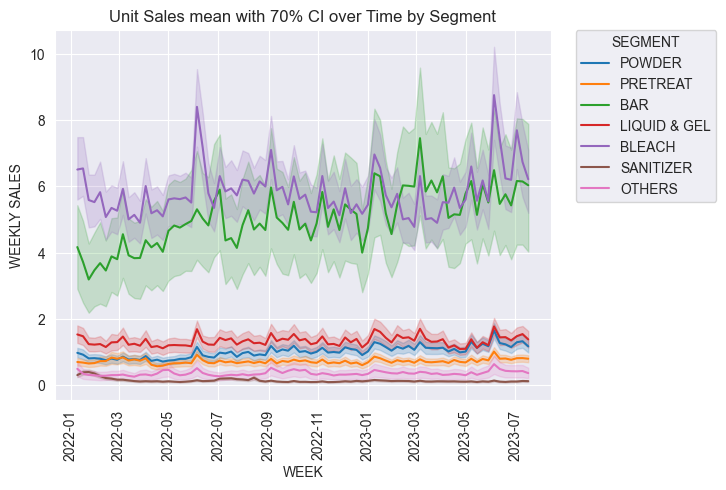

In [70]:
fig, ax = plt.subplots()

sns.lineplot(df_clave, x='WEEK', y='WEEKLY_SALES', hue='SEGMENT', ax=ax, errorbar=('ci', 70))
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='SEGMENT')
plt.title('Unit Sales mean with 70% CI over Time by Segment')
plt.savefig('Linea temporal por segmento.png')
plt.show()

Observando la línea de tiempo de las ventas semanales por segmento (están plasmadas las medias de cada segmento por semana, junto con un área de error representando el intervalo de confianza del 70%), se puede ver que lo observado en la figura anterior no fue debido a una época específica con muy altas ventas, sino que la dominancia de los segmentos "BAR" y "BLEACH" es consistente con el tiempo. Aún así, su margen de error es muy alto en comparación con los demás. "BAR" empezó con ventas relativamente bajas en 2022, pero para julio de ese mismo año, sus ventas subieron al punto de competir directamente con "BLEACH", incluso superándolo para inicios de 2023. En cambio, "BLEACH" ha tenido una ligera caída desde 2022, pero en general se ha mantenido constante pero con muchas fluctuaciones. Esto es contrastante con los demás segmentos que cuentan con ventas mucho menores y líneas temporales casi planas y con muy pocas fluctuaciones. Es importante destacar que en casi todos los segmentos hay picos en las mismas fechas, como los presentes en marzo, junio y septiembre de 2022, en enero, marzo y junio de 2023, indicando que por estos meses hay temporadas de ofertas o altas demandas de consumo en todos los productos.

C:\Users\Joseph\AppData\Local\Temp\ipykernel_22264\2808791910.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


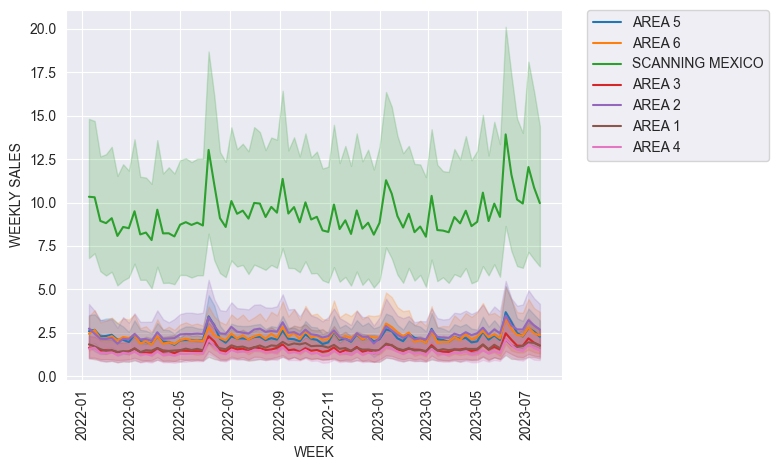

In [69]:
fig, ax = plt.subplots()

sns.lineplot(df_clave, x='WEEK', y='WEEKLY_SALES', hue='REGION', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

Vemos que no hay una diferencia muy clara si clasificamos por regiones a todas las ventas, más allá de la constante dominancia sobre el tiempo de las ventas de "SCANNING MEXICO" sobre las demás regiones. Sin embargo, podemos hacer esta división para cada segmento

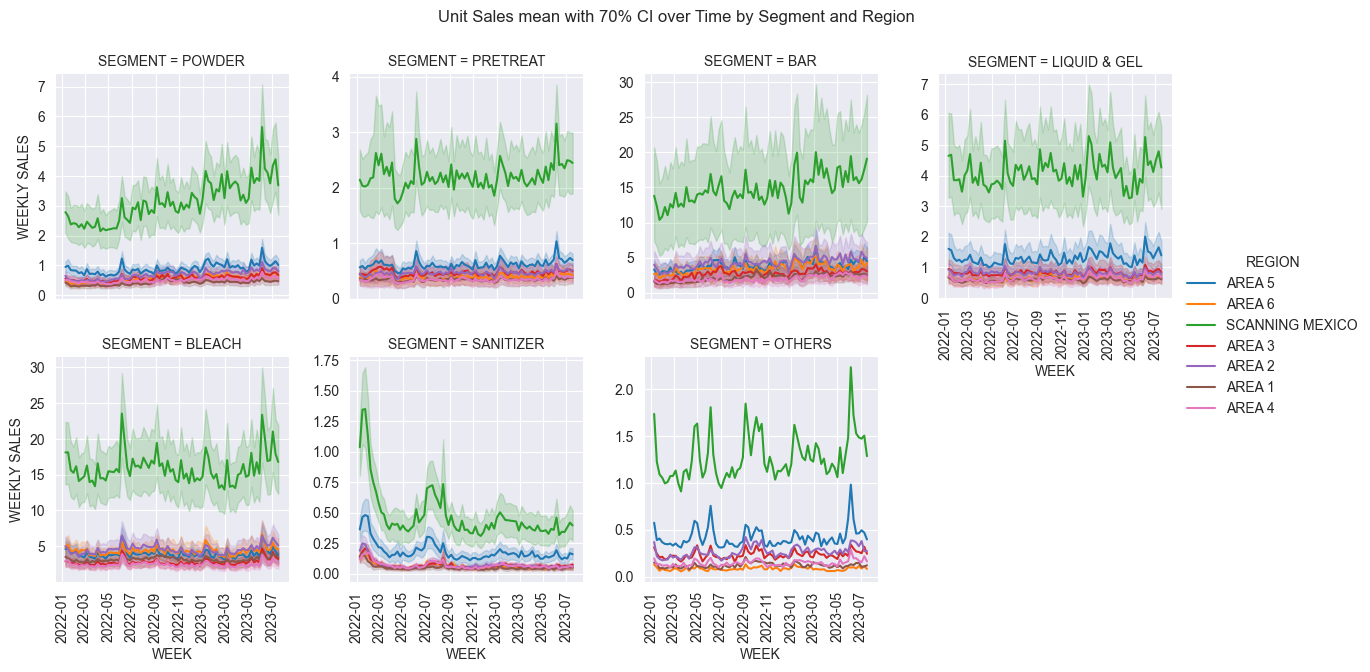

In [75]:
graf=sns.FacetGrid(df_clave, col='SEGMENT', hue='REGION', sharey=False, col_wrap=4)
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES', errorbar=('ci', 70)) 
graf.figure.suptitle('Unit Sales mean with 70% CI over Time by Segment and Region', y=1.05)

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat] #Comando para rotar 90 grados los xticks labels, dado que son fechas
graf.add_legend()
graf.set_ylabels('WEEKLY SALES')
plt.savefig('Linea temporal por segmento y por region.png')
plt.show()

Incluso dividiendo las ventas por segmentos, podemos notar que las ventas de "SCANNING MEXICO" siguen dominando en todos los segmentos. Dado que la empresa Reckitt está interesada en el rendimiento de los sanitizantes, una buena sugerencia sería aumentar la cantidad de productos en venta en esta región, así como en "AREA 5", donde también se observa un buen rendimiento en las ventas.

Cabe destacar que los ejes 'y' de cada gráfica son diferentes, por lo que no se puede comparar (visualmente) en esta figura las ventas entre cada segmento.

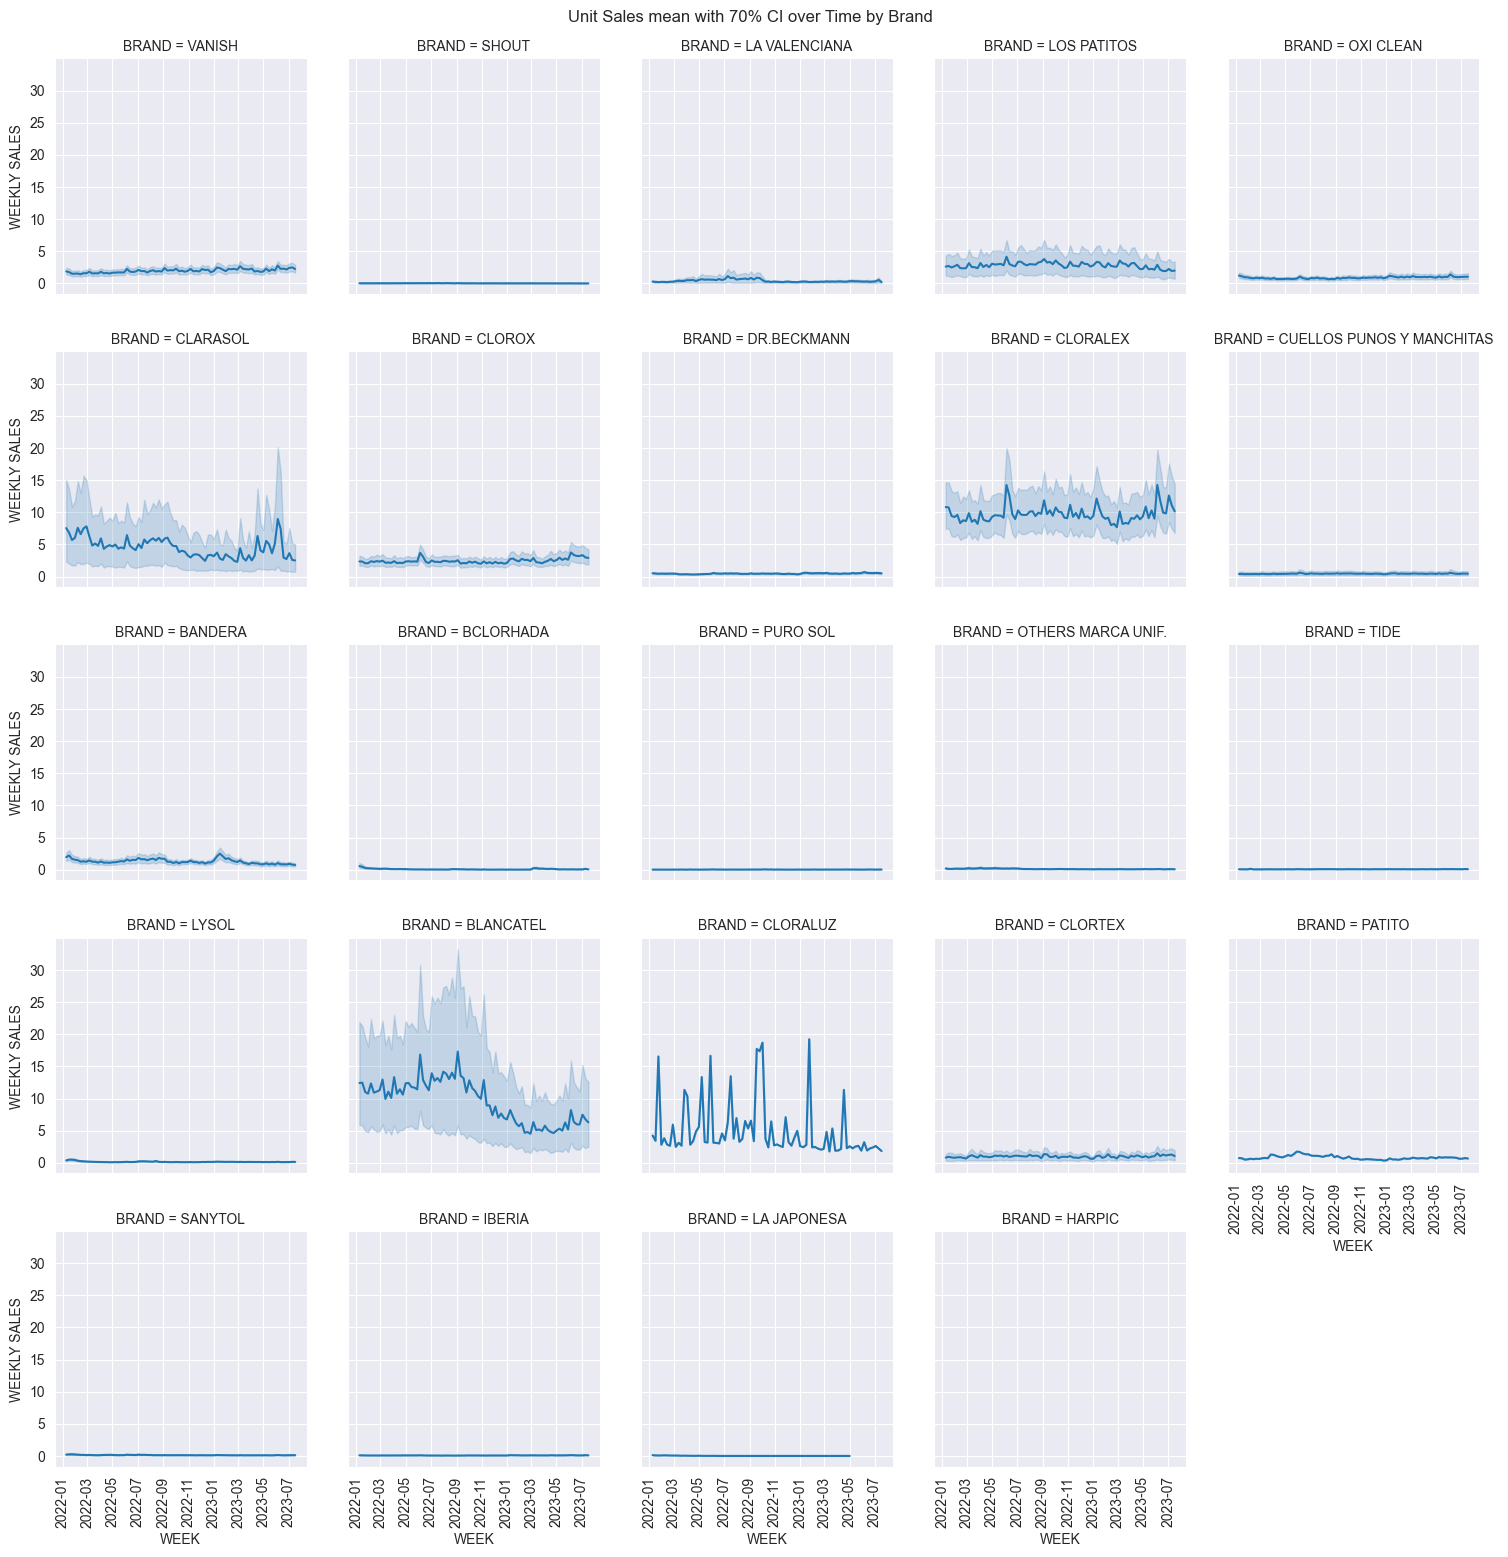

In [ ]:
graf=sns.FacetGrid(df_clave, col='BRAND', col_wrap=5) 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES', errorbar=('ci', 70)) 
graf.figure.suptitle('Unit Sales mean with 70% CI over Time by Brand', y=1.01)

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.show()

Al intentar comparar las líneas temporales entre marcas, encontramos el problema de que la marca "HARPIC" parece no tener datos de ventas. En la sigiente figura, se eliminará esta marca para que se pueda comparar mejor las demás marcas.

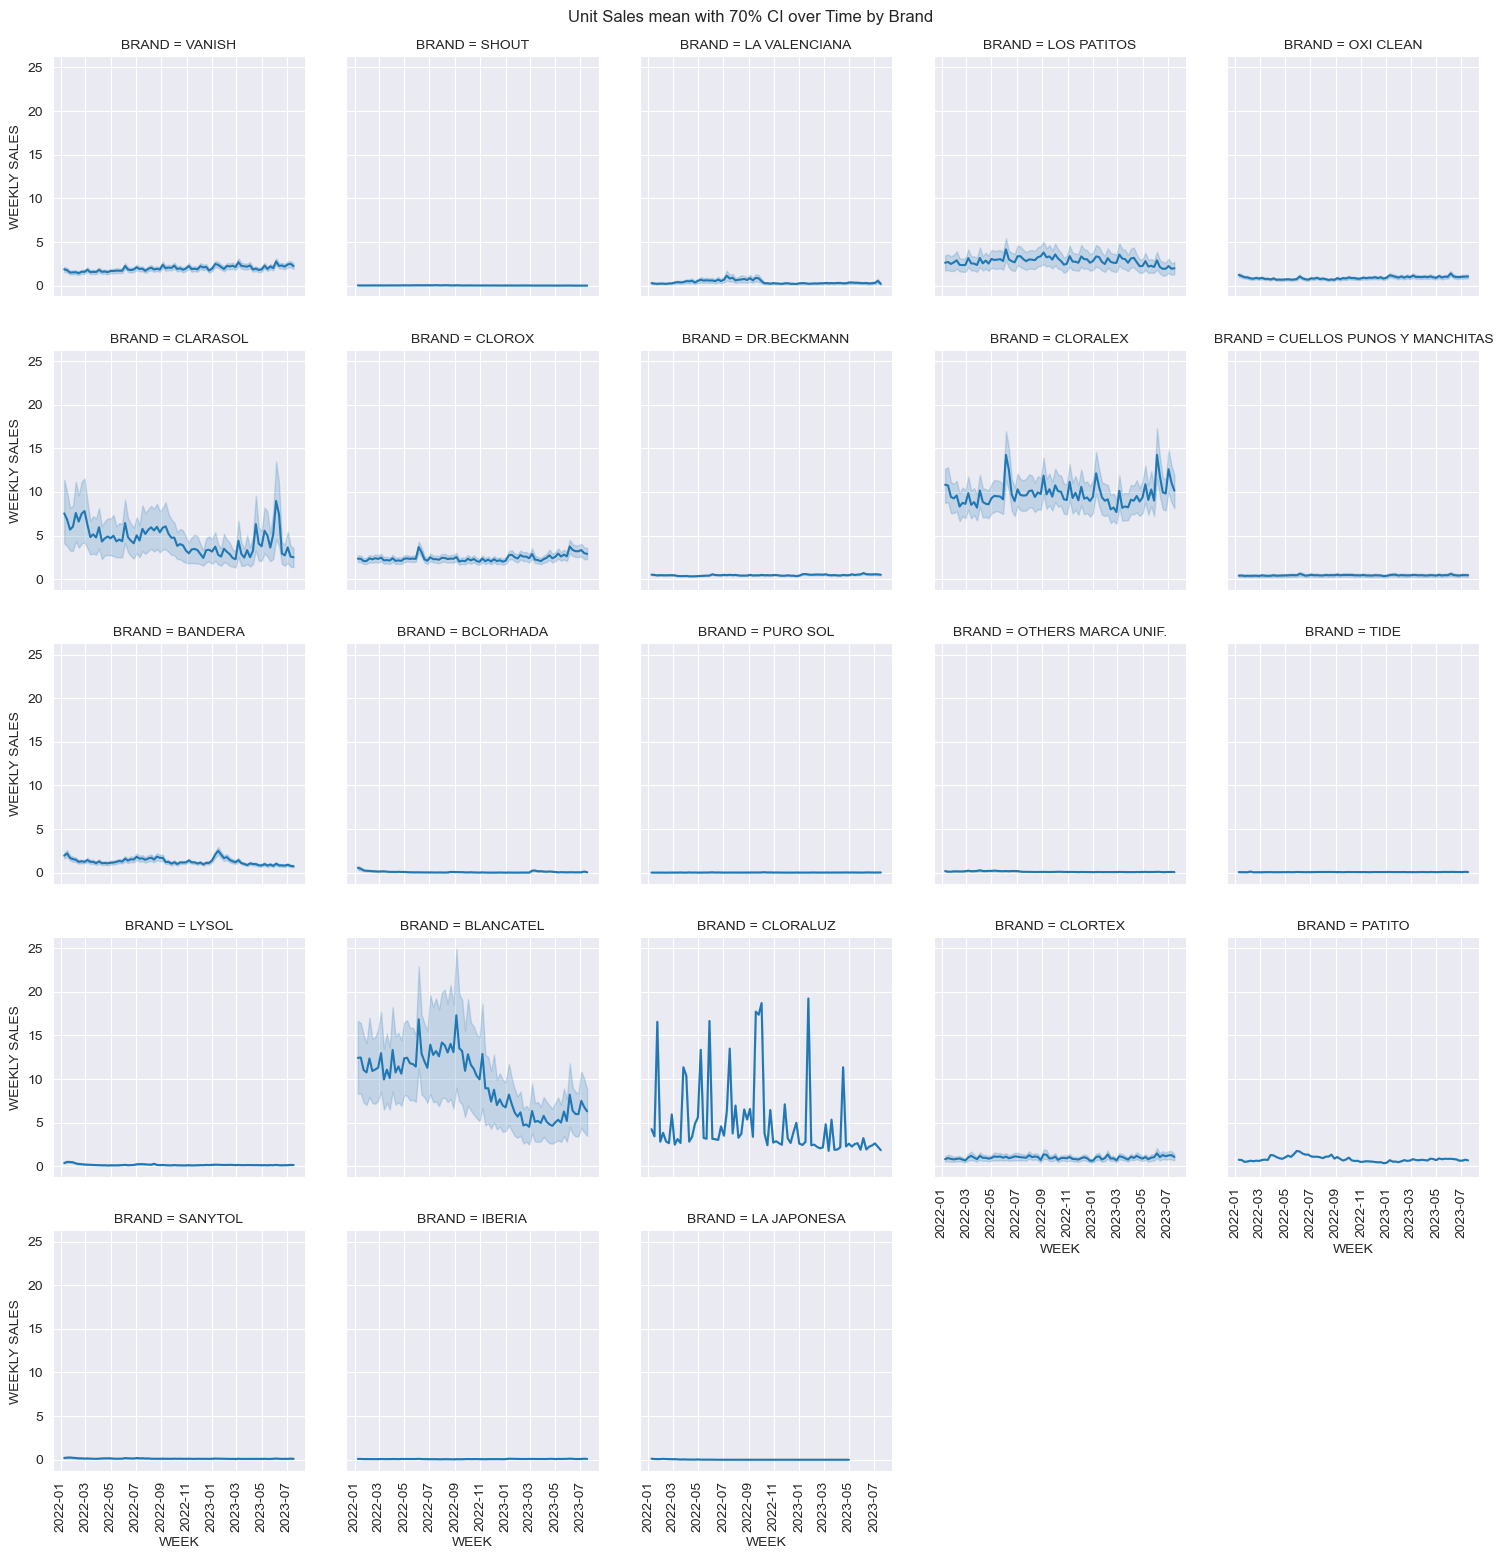

In [14]:
graf=sns.FacetGrid(df_clave[df_clave['BRAND']!='HARPIC'], col='BRAND', col_wrap=5) 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES', errorbar=('ci', 70)) 
graf.figure.suptitle('Unit Sales mean with 70% CI over Time by Brand', y=1.01)

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.savefig('Linea temporal por marca.png')
plt.show()

Observamos que muchas de las marcas presentadas tienen líneas temporales muy planas y cercanas a 0, como lo son lamentablemente, la marca "LYSOL". "VANISH", por su parte, no destaca por la media de sus ventas, pero sí está por encima de muchas de las marcas mencionadas anteriormente, teniendo un ligero pero constante crecimiento con el paso del tiempo. Pasando a las marcas con mayores ventas, existen algunas que se han mantenido bien en el mercado como "CLORALEX", "CLARASOL" y "LOS PATITOS", pero hay otras como "BLANCATEL" que han tenido un decrecimiento de ventas conforme pasó el año 2022 y 2023; o también está el caso de la marca "CLORALUZ", que si bien ha tenido medias de ventas muy altas en ciertas semanas, su línea de tiempo es muy caótica y parece que son muy pocos los datos de ventas registrados de esta marca, dada la casi nula área de error dibujada. 

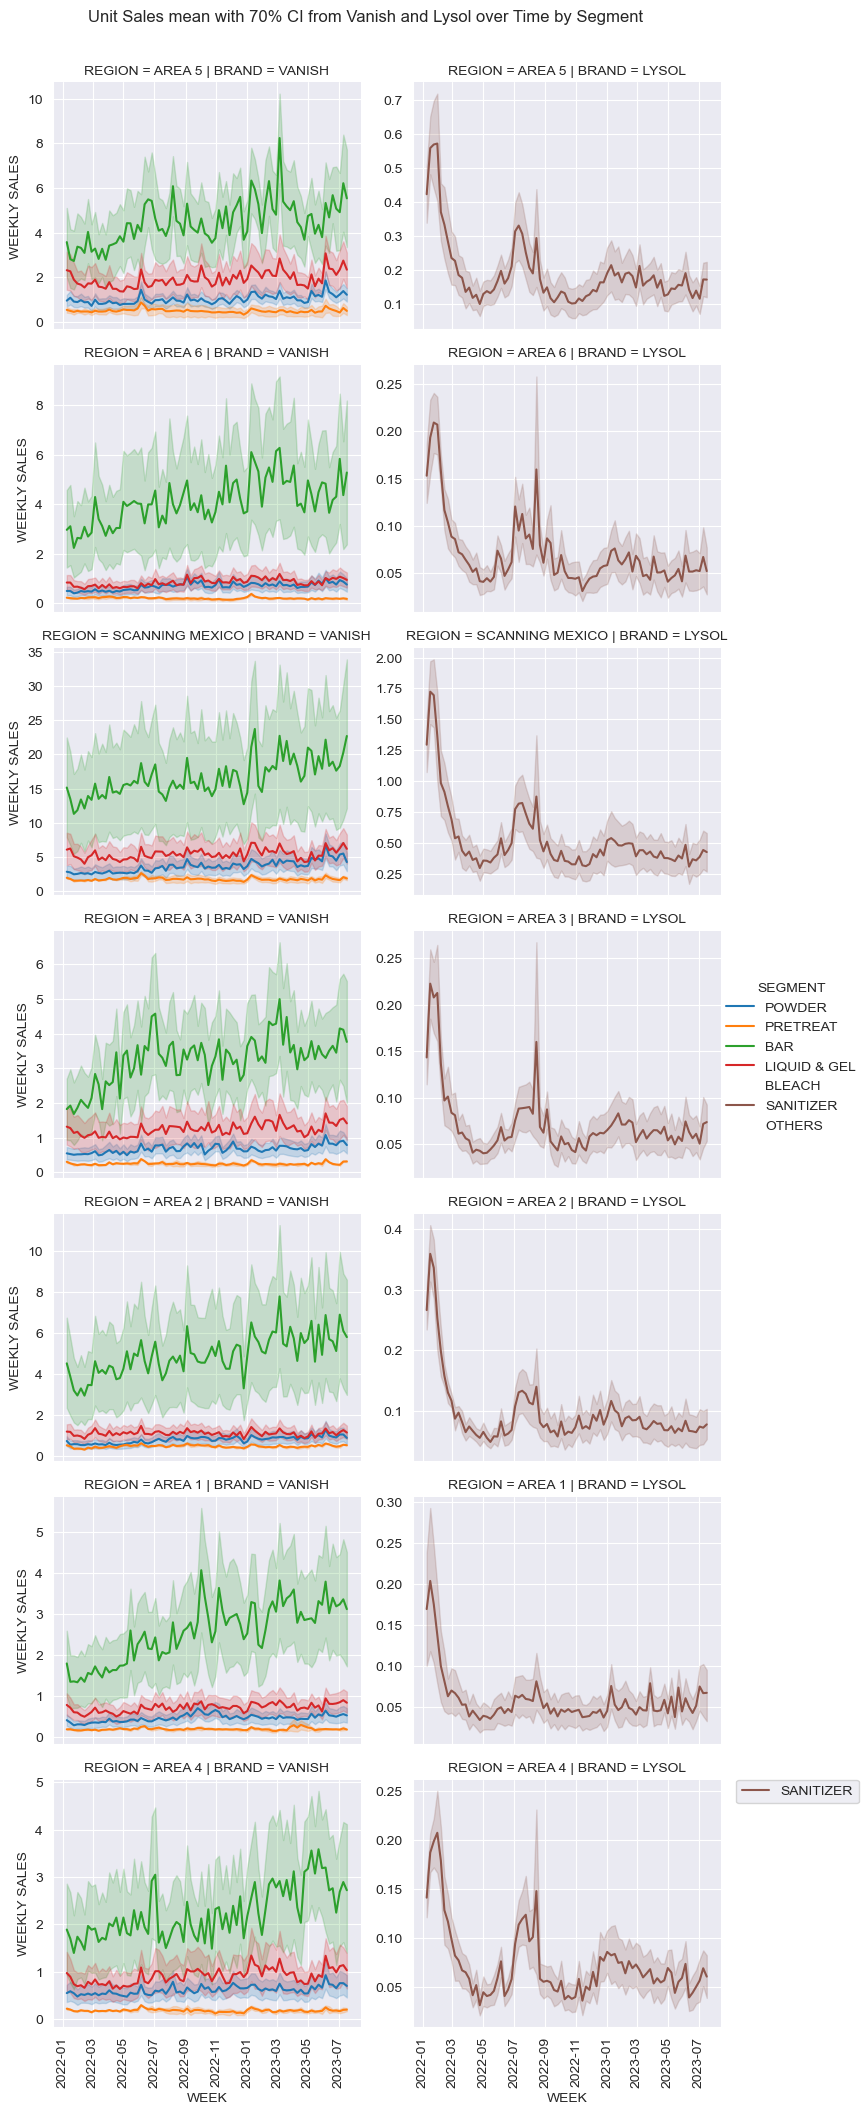

In [13]:
graf=sns.FacetGrid(df_clave, col='BRAND', row='REGION', col_order=['VANISH', 'LYSOL'], hue='SEGMENT', sharey=False) 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES', errorbar=('ci', 70)) 
graf.figure.suptitle('Unit Sales mean with 70% CI from Vanish and Lysol over Time by Segment', y=1.005)

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.savefig('Linea temporal por segmento y por region para Vanish y Lysol.png')
plt.show()

Haciendo hincapié en las marcas "VANISH" y "LYSOL", se realizó esta gráfica que muestra a detalle las líneas temporales de las ventas de los productos de estas marcas divididas por región y segmento cada una. Podemos ver que "VANISH" realmente ha tenido un muy buen rendimiento en los productos tipo "BAR", sobrepasando en gran medida a los otros segmentos, teniendo además un crecimiento con el paso del tiempo. "LYSOL" presenta un rendimiento muy malo todavía, dado que solo se enuentra en el segmento de "SANITIZER", teniendo un pico relativo de ventas a inicios de 2022, pero que bajó drásticamente hasta tener otro pico considerable en agosto de 2022, teniendo después una caída casi constante en ventas. 

Comparando entre regiones, se observa que en "SCANNING MEXICO", en el "AREA 5" y en el "AREA 6", los productos de "VANISH" tipo "BAR" tienen el mejor rendimiento, pero el mayor número de fluctuaciones y altos margenes de error, mientras que en el "AREA 4", "AREA 2" y "AREA 1" cuenta con un crecimiento en la tendencia de las ventas en todo el periodo registrado.